# It Takes Time: Intensity-Aware Sequential Recommendation Benchmark

Goal: rank a battery of sequential / temporal collaborative-filtering models on
**MovieLens-1M** and **Steam-200k** under a single, reproducible methodology, and
produce results tables that compare standard SOTA baselines against three new
**IA-SASRec** (Intensity-Aware SASRec) variants that inject per-interaction
intensity (ratings / hours-played) directly into the self-attention mechanism.

**Models compared**

| Family | Models |
|---|---|
| Non-sequential baselines | `Pop`, `BPR`, `ItemKNN` |
| Sequential SOTA | `FPMC`, `GRU4Rec`, `NARM`, `SASRec`, `BERT4Rec` |
| **IA-SASRec (new)** | `IA-SASRec-Add`, `IA-SASRec-Mul`, `IA-SASRec-Val` |

**Methodology**

- Datasets: ML-1M (rating as intensity), Steam-200k (hours-played as intensity).
  Both filtered to users/items with >= 5 interactions.
- Split: leave-one-out per user, sorted chronologically (`LS=valid_and_test`, `order=TO`).
- HPO: Optuna TPE + MedianPruner, `N_TRIALS=10` by default.
- Eval: full-vocabulary scoring -> HitRate, NDCG, MRR, Recall, Precision @ {10, 20, 50, 100}.
- Resumability: results persisted to `results/eval/<dataset>__<model>.json`;
  Optuna studies persist to SQLite under `results/hpo/`.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import optuna

import config
from data import prepare_recbole_dataset, dataset_stats
from models import MODEL_REGISTRY, list_models
from hpo import run_optuna
from runner import train_and_eval, has_result, load_result
from evaluation import aggregate_results, top_k_recommend

print('device:', config.DEVICE)
print('models:', list_models())
print('N_TRIALS:', config.N_TRIALS, '| HPO_EPOCHS:', config.HPO_EPOCHS, '| FINAL_EPOCHS:', config.FINAL_EPOCHS)

2026-05-18 10:30:42.072774: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-18 10:30:42.144323: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-18 10:30:43.778348: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


device: cuda
models: ['Pop', 'BPR', 'ItemKNN', 'FPMC', 'GRU4Rec', 'NARM', 'SASRec', 'BERT4Rec', 'IA-SASRec-Add', 'IA-SASRec-Mul', 'IA-SASRec-Val']
N_TRIALS: 10 | HPO_EPOCHS: 10 | FINAL_EPOCHS: 50


## 2. Dataset preparation

Downloads MovieLens-1M (~6 MB) on first run, converts to RecBole atomic-file
format, and caches under `recbole_data/ml-1m/ml-1m.inter`. Subsequent runs are no-ops.

In [2]:
DATASETS = ['ml-1m', 'steam']
stats_all = {}
for ds in DATASETS:
    try:
        prepare_recbole_dataset(ds)
        stats_all[ds] = dataset_stats(ds)
    except Exception as e:
        print(f'[skip] {ds}: {e}')
pd.DataFrame(stats_all).style.format('{:.4f}')

[data] Downloading Kaggle dataset tamber/steam-video-games via kagglehub ...


100%|██████████| 1.46M/1.46M [00:00<00:00, 2.37MB/s]

Extracting files...


[data] Copied /home/coder/.cache/kagglehub/datasets/tamber/steam-video-games/versions/3/steam-200k.csv -> /home/coder/projects/phd/rec-sys-research/it_takes_time/data/steam/steam-200k.csv
[data] Wrote /home/coder/projects/phd/rec-sys-research/it_takes_time/recbole_data/steam/steam.inter  (70,489 interactions, 11,350 users, 3,600 items, intensity range [0.10, 11754.00])


,ml-1m,steam
interactions,1000209.0000,70489.0000
users,6040.0000,11350.0000
items,3706.0000,3600.0000
density,0.0447,0.0017
min_ts,956703932.0000,0.0000
max_ts,1046454590.0000,70488.0000
intensity_min,1.0000,0.1000
intensity_max,5.0000,11754.0000
intensity_mean,3.5816,48.8781


## 3. Run benchmark (resumable)

Loops the model registry. For each model:

1. If `results/eval/<dataset>__<model>.json` exists → load it, skip training.
2. Otherwise: run Optuna HPO, then a final fit on the best params, persist JSON.

Interrupt at any point; re-running this cell continues from the next un-evaluated model.

In [ ]:
MODELS_TO_RUN = list_models()  # includes IA-SASRec-Add / -Mul / -Val
DATASETS_TO_RUN = [ds for ds in DATASETS if ds in stats_all]

results = {}
for ds in DATASETS_TO_RUN:
    print(f'\n########## dataset = {ds} ##########')
    for name in MODELS_TO_RUN:
        print(f'\n=== {ds} / {name} ===')
        if has_result(ds, name):
            r = load_result(ds, name)
            results[(ds, name)] = r
            print(f'  cached -> NDCG@10={r["test_result"].get("ndcg@10"):.4f}')
            continue
        hpo_out = run_optuna(ds, name)
        print(f'  HPO best_value={hpo_out["best_value"]} params={hpo_out["best_params"]}')
        r = train_and_eval(ds, name, best_params=hpo_out['best_params'])
        results[(ds, name)] = r
        print(f'  final NDCG@10={r["test_result"].get("ndcg@10"):.4f}')

print('\nAll done.')


########## dataset = ml-1m ##########

=== ml-1m / Pop ===
  cached -> NDCG@10=0.0177

=== ml-1m / BPR ===
  cached -> NDCG@10=0.0341

=== ml-1m / ItemKNN ===
  cached -> NDCG@10=0.0372

=== ml-1m / FPMC ===
  cached -> NDCG@10=0.0813

=== ml-1m / GRU4Rec ===
  cached -> NDCG@10=0.1436

=== ml-1m / NARM ===
  cached -> NDCG@10=0.1163

=== ml-1m / SASRec ===
  cached -> NDCG@10=0.1272

=== ml-1m / BERT4Rec ===
  cached -> NDCG@10=0.1237

=== ml-1m / IA-SASRec-Add ===
  cached -> NDCG@10=0.1340

=== ml-1m / IA-SASRec-Mul ===
  cached -> NDCG@10=0.1516

=== ml-1m / IA-SASRec-Val ===
  cached -> NDCG@10=0.1411

########## dataset = steam ##########

=== steam / Pop ===
[hpo] Pop: empty search space, skipping HPO.
  HPO best_value=None params={}
[runner] Pop: saved to /home/coder/projects/phd/rec-sys-research/it_takes_time/results/eval/steam__Pop.json
  final NDCG@10=0.2604

=== steam / BPR ===
[hpo] BPR: running 10 new trials (already have 0).
[hpo] BPR: trial 1/10 (COMPLETE) value=0.1935

## 4. Results table

In [ ]:
key_cols = ['model', 'hit@10', 'ndcg@10', 'mrr@10', 'recall@10', 'hit@100', 'ndcg@100', 'train_seconds']
tables = {}
for ds in DATASETS_TO_RUN:
    df = aggregate_results(ds)
    cols = [c for c in key_cols if c in df.columns]
    tables[ds] = df[cols].round(4)
    print(f'\n--- {ds} ---')
    print(tables[ds].to_string(index=False))
df = tables[DATASETS_TO_RUN[0]]
df


--- ml-1m ---
        model  hit@10  ndcg@10  mrr@10  recall@10  hit@100  ndcg@100  train_seconds
IA-SASRec-Mul  0.2727   0.1516  0.1148     0.2727   0.6522    0.2285      4236.4122
      GRU4Rec  0.2467   0.1436  0.1121     0.2467   0.6151    0.2178       644.7153
IA-SASRec-Val  0.2603   0.1411  0.1049     0.2603   0.6296    0.2160      2731.3424
IA-SASRec-Add  0.2485   0.1340  0.0993     0.2485   0.6308    0.2116      1501.3556
       SASRec  0.2444   0.1272  0.0916     0.2444   0.6313    0.2051      1952.1426
     BERT4Rec  0.2359   0.1237  0.0898     0.2359   0.6248    0.2024      2472.9895
         NARM  0.2247   0.1163  0.0834     0.2247   0.6127    0.1942       468.2525
         FPMC  0.1599   0.0813  0.0574     0.1599   0.5063    0.1494       514.5932
      ItemKNN  0.0745   0.0372  0.0261     0.0745   0.3639    0.0927        21.3152
          BPR  0.0684   0.0341  0.0239     0.0684   0.3609    0.0901        91.2732
          Pop  0.0368   0.0177  0.0120     0.0368   0.2257   

,model,hit@10,ndcg@10,mrr@10,recall@10,hit@100,ndcg@100,train_seconds
0,IA-SASRec-Mul,0.2727,0.1516,0.1148,0.2727,0.6522,0.2285,4236.4122
1,GRU4Rec,0.2467,0.1436,0.1121,0.2467,0.6151,0.2178,644.7153
2,IA-SASRec-Val,0.2603,0.1411,0.1049,0.2603,0.6296,0.2160,2731.3424
3,IA-SASRec-Add,0.2485,0.1340,0.0993,0.2485,0.6308,0.2116,1501.3556
4,SASRec,0.2444,0.1272,0.0916,0.2444,0.6313,0.2051,1952.1426
5,BERT4Rec,0.2359,0.1237,0.0898,0.2359,0.6248,0.2024,2472.9895
6,NARM,0.2247,0.1163,0.0834,0.2247,0.6127,0.1942,468.2525
7,FPMC,0.1599,0.0813,0.0574,0.1599,0.5063,0.1494,514.5932
8,ItemKNN,0.0745,0.0372,0.0261,0.0745,0.3639,0.0927,21.3152
9,BPR,0.0684,0.0341,0.0239,0.0684,0.3609,0.0901,91.2732


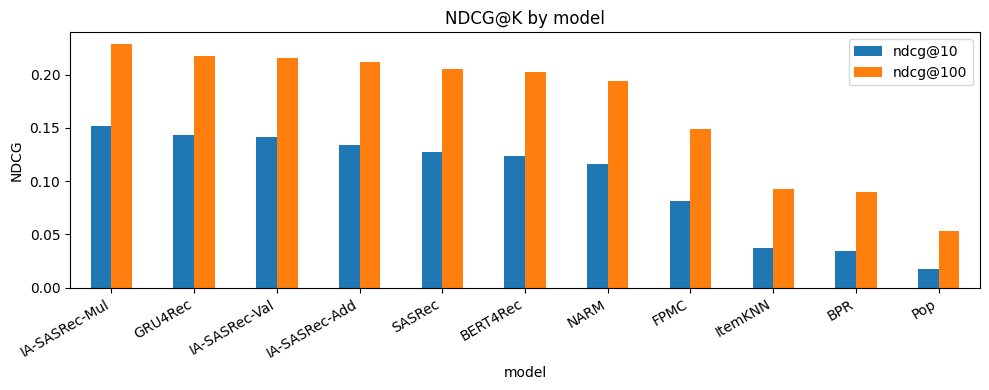

In [ ]:
import matplotlib.pyplot as plt
ax = df.set_index('model')[[c for c in ['ndcg@10', 'ndcg@20', 'ndcg@50', 'ndcg@100'] if c in df.columns]].plot.bar(figsize=(10, 4))
ax.set_ylabel('NDCG'); ax.set_title('NDCG@K by model'); plt.xticks(rotation=30, ha='right'); plt.tight_layout()

## 5. Top-100 recommendations demo

Confirms the "next-1 → top-K" path: we score the entire item vocab at the next
position, mask items already in the user's history, and take the top 100. The
model below is reloaded from its checkpoint.

In [ ]:
from pathlib import Path
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.utils import get_model, get_trainer, init_seed

best_model_name = df.iloc[0]['model']
print('Best model:', best_model_name)
rec = load_result(DATASET, best_model_name)
# Rebase checkpoint to local CHECKPOINT_DIR (results may have been produced on another machine).
ckpt = str(config.CHECKPOINT_DIR / Path(rec['checkpoint']).name)

# Rebuild config + dataset and load checkpoint
from runner import _build_config
cfg, model_cls = _build_config(DATASET, best_model_name, rec.get('best_params') or {}, epochs=1, saved=True)
init_seed(cfg['seed'], cfg['reproducibility'])
dataset = create_dataset(cfg)
train_data, valid_data, test_data = data_preparation(cfg, dataset)
model_class = model_cls or get_model(cfg['model'])
model = model_class(cfg, train_data._dataset).to(cfg['device'])
model.load_state_dict(torch.load(ckpt, map_location=cfg['device'])['state_dict'])
model.eval()

sample_users = list(dataset.id2token(dataset.uid_field, np.arange(1, 4)))
topk = top_k_recommend(model, dataset, test_data, sample_users, k=100)
topk.head(15)

Best model: IA-SASRec-Mul


NameError: name 'DATASET' is not defined

## 6. Analysis

In [ ]:
# Quick sequential-vs-non-sequential gap
is_seq = {n: (MODEL_REGISTRY[n]['type'] == 'sequential') for n in df['model']}
df_analysis = df.copy()
df_analysis['family'] = df_analysis['model'].map(lambda n: 'sequential' if is_seq[n] else 'general')
df_analysis.groupby('family')[[c for c in ['ndcg@10', 'hit@10', 'mrr@10'] if c in df_analysis.columns]].mean().round(4)

## 7. Adding a custom variant

For your next paper, drop a class into [`src/models/variants/`](../src/models/variants/)
and register it. Example:

```python
# src/models/variants/sasrec_plus.py
from recbole.model.sequential_recommender.sasrec import SASRec
import torch.nn as nn

class SASRecPlus(SASRec):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.extra_proj = nn.Linear(self.hidden_size, self.hidden_size)
    def forward(self, item_seq, item_seq_len):
        out = super().forward(item_seq, item_seq_len)
        return out + self.extra_proj(out)  # toy modification
```

Then in [`src/models/__init__.py`](../src/models/__init__.py):

```python
from models.variants.sasrec_plus import SASRecPlus
MODEL_REGISTRY['SASRecPlus'] = {
    'class': SASRecPlus,
    'type': 'sequential',
    'search_space': sasrec_space,
    'static': _seq_static(),
}
```

Re-run section 3 — only `SASRecPlus` will train; everything else loads from disk.